# About this notebook

In this notebook I am analyzing the database to derive insights, which are going  to be used in feature engineering and selection, and the parts that come afterward.

 Through these insights I will decide which models are best for this project and also decide how they should work.


# Imports

In [116]:
import numpy as np
import pandas as pd
from src.dataset.loader import load_cicids2017_dataset
from src.preprocessing.validator import validate_schema, validate_rules
from src.preprocessing.result import ValidationResult
from src.core.config import load_validation_schema, load_validation_rules, load_cleaning_configuration
from src.preprocessing.cleaning import clean
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

# Loading dataset

In [141]:
dataset_dir = '../dataset'

df = load_cicids2017_dataset(dataset_dir)

df.info()
print(df.head())

<class 'pandas.DataFrame'>
Index: 2830743 entries, 0 to 692702
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max                 int64  
 

# Checking for class imbalance

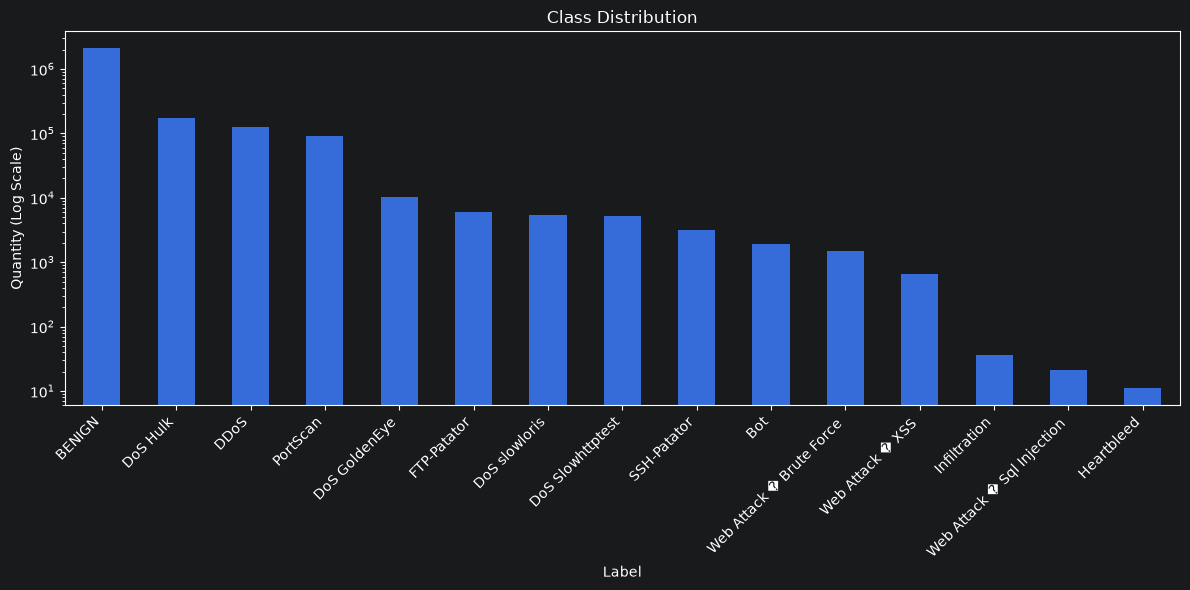

In [142]:
df.columns = df.columns.str.strip()
df.drop_duplicates(inplace=True)

label_counts = df['Label'].value_counts()

plt.figure(figsize = (12, 6))
label_counts.plot(kind = 'bar')

plt.yscale('log')

plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution")
plt.ylabel("Quantity (Log Scale)")
plt.tight_layout()
plt_path = Path('../out/plots/')
plt_path.mkdir(exist_ok=True, parents=True)
plt.savefig(Path(plt_path, 'class_distribution.png'))
plt.show()

Looking at the barchart, there is heavy class imbalance. I think I should **implement SMOTE** to handle this.

# Data validation

In [69]:
pd.set_option("display.float_format", "{:.2f}".format)
df.max(numeric_only=True)

Destination Port                  65535.00
Flow Duration                 119999998.00
Total Fwd Packets                219759.00
Total Backward Packets           291922.00
Total Length of Fwd Packets    12900000.00
                                  ...     
Active Min                    110000000.00
Idle Mean                     120000000.00
Idle Std                       76900000.00
Idle Max                      120000000.00
Idle Min                      120000000.00
Length: 78, dtype: float64

Looking at the above table, the best datatype for storing these **values is float32 and int32**, will **need to remove the np.inf** values.

In [70]:
df.min(numeric_only=True)

Destination Port                0.00
Flow Duration                 -13.00
Total Fwd Packets               1.00
Total Backward Packets          0.00
Total Length of Fwd Packets     0.00
                               ...  
Active Min                      0.00
Idle Mean                       0.00
Idle Std                        0.00
Idle Max                        0.00
Idle Min                        0.00
Length: 78, dtype: float64

In the above minimum values, it can be seen that some columns which are negative cannot be valid:

1. Flow duration: cannot be negative as it is time.
2. Flow bytes/s: Bytes transferred cannot be negative.
3. Flow packets/s: same reason as no.2
4. IAT statistics: Time difference cannot be negative if packets are ordered correctly.
5. Header Lengths: these are sum of bytes and cannot be negative.
6. Segment size: are length in bytes, cannot be negative.
7. Init_Win_bytes_forward and backward can be negative if the protocol is not TCP.

In [71]:
negative_counts = (df.select_dtypes(include="number") < 0).sum()
negative_counts[negative_counts > 0]

Flow Duration                  107
Flow Bytes/s                    78
Flow Packets/s                 107
Flow IAT Mean                  107
Flow IAT Max                   107
Flow IAT Min                  2881
Fwd IAT Min                     17
Fwd Header Length               35
Bwd Header Length               22
Fwd Header Length.1             35
Init_Win_bytes_forward      911027
Init_Win_bytes_backward    1216341
min_seg_size_forward            35
dtype: int64

In [72]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        print(col, df[df[col] < 0][col].unique())

Destination Port []
Flow Duration [ -1 -12 -13  -2  -4]
Total Fwd Packets []
Total Backward Packets []
Total Length of Fwd Packets []
Total Length of Bwd Packets []
Fwd Packet Length Max []
Fwd Packet Length Min []
Fwd Packet Length Mean []
Fwd Packet Length Std []
Bwd Packet Length Max []
Bwd Packet Length Min []
Bwd Packet Length Mean []
Bwd Packet Length Std []
Flow Bytes/s [-1.20000000e+07 -1.93000000e+08 -8.00000000e+06 -6.66666667e+05
 -6.00000000e+06 -4.61538461e+05 -4.00000000e+06 -1.00000000e+06
 -2.61000000e+08]
Flow Packets/s [-2000000.      -166666.6667  -153846.1538 -1000000.      -500000.    ]
Flow IAT Mean [ -1. -12. -13.  -2.  -4.]
Flow IAT Std []
Flow IAT Max [ -1 -12 -13  -2  -4]
Flow IAT Min [ -1 -12  -3  -2 -10 -11 -13  -5  -4  -6 -14  -8]
Fwd IAT Total []
Fwd IAT Mean []
Fwd IAT Std []
Fwd IAT Max []
Fwd IAT Min [-12  -1  -8]
Bwd IAT Total []
Bwd IAT Mean []
Bwd IAT Std []
Bwd IAT Max []
Bwd IAT Min []
Fwd PSH Flags []
Bwd PSH Flags []
Fwd URG Flags []
Bwd URG Flag

From the output, it seems dataset has invalid values, integer overflows and other issues.
Upon checking on internet, I learned this dataset (CICIDS2017) is made using CICFlowMeter, bugs in it may have caused these issues, as in real world similar situations may repeat it'd be wiser to **make a validator.**

I should also **account for missing values, NaN and inf** in the validator.

For now though, I'll just drop the invalid values and proceed with EDA.

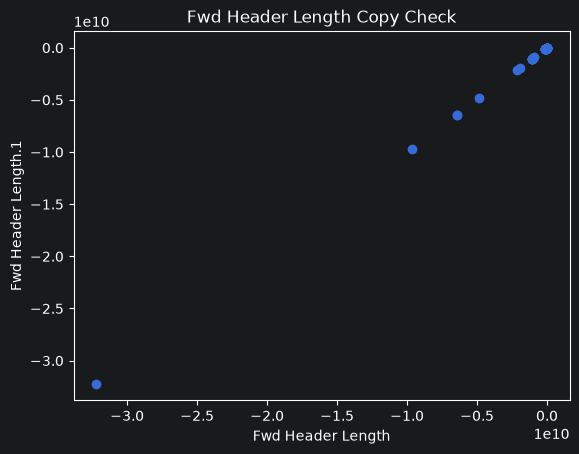

In [73]:
plt.scatter(df["Fwd Header Length"], df["Fwd Header Length.1"])
plt.title('Fwd Header Length Copy Check')
plt.xlabel("Fwd Header Length")
plt.ylabel("Fwd Header Length.1")
plt.savefig(Path(plt_path, 'Fwd Header Length Copy Check.png'))
plt.show()

As expected the Fwd Header Length.1 column is identical to Fwd Header Length, better drop the copy.

In [74]:
df.drop(columns=["Fwd Header Length.1"], inplace=True)

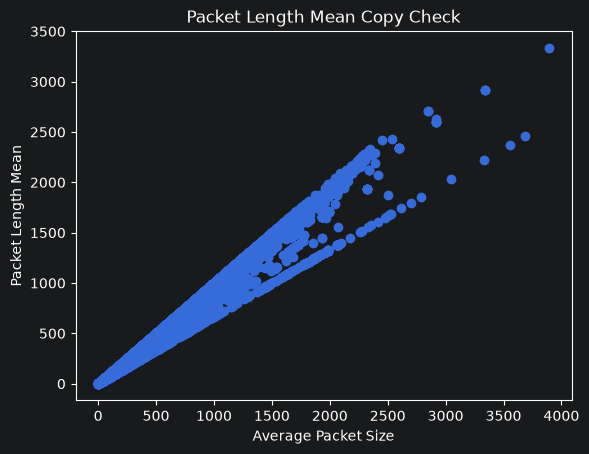

In [75]:
plt.scatter(df['Average Packet Size'], df['Packet Length Mean'])
plt.title("Packet Length Mean Copy Check")
plt.xlabel("Average Packet Size")
plt.ylabel("Packet Length Mean")
plt.savefig(Path(plt_path, 'Packet Length Mean Copy Check.png'))
plt.show()

These two do not seem completely identical, but, I should investigate more in depth.

In [76]:
print(df[["Average Packet Size",
    "Packet Length Mean"]].corr().round(12))

diff = (
    df["Average Packet Size"]
    - df["Packet Length Mean"]
)
print()
print(diff.describe())
print()

ratio = (
    df["Average Packet Size"]
    / df["Packet Length Mean"]
)
print()
print(ratio.describe())
print()
print(ratio.round(4).value_counts().head(20))

                     Average Packet Size  Packet Length Mean
Average Packet Size                 1.00                1.00
Packet Length Mean                  1.00                1.00

count   2522362.00
mean         21.77
std          34.87
min           0.00
25%           2.75
50%          12.00
75%          24.95
max        1228.00
dtype: float64


count   2244505.00
mean          1.25
std           0.17
min           1.00
25%           1.08
50%           1.25
75%           1.50
max           1.50
dtype: float64

1.25    675810
1.50    573804
1.17     93066
1.08     69307
1.33     67946
1.07     62360
1.12     61605
1.08     54659
1.07     49170
1.14     45586
1.11     40478
1.20     37796
1.06     27155
1.09     25865
1.10     22996
1.06     19736
1.03     18176
1.06     15732
1.05     14737
1.05     12814
Name: count, dtype: int64


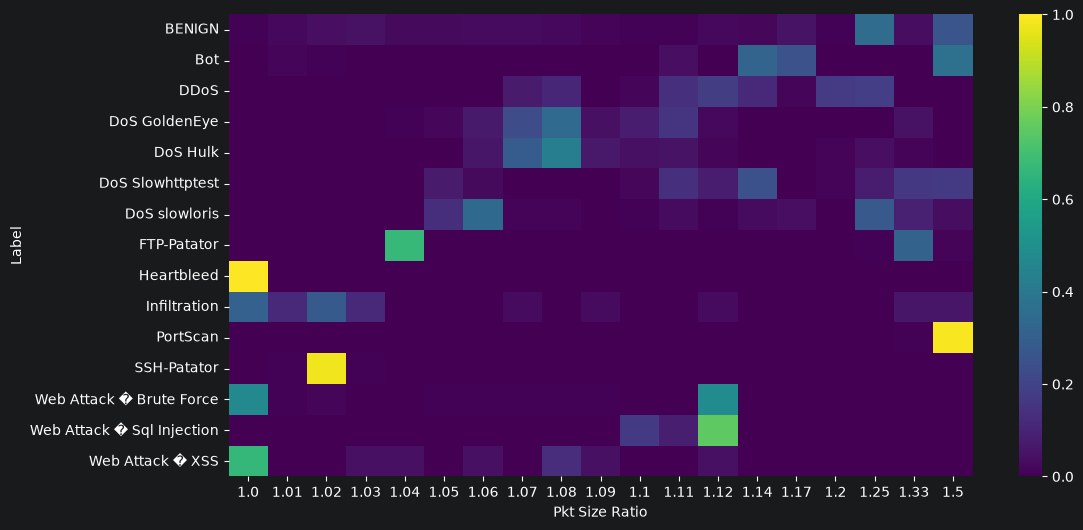

In [77]:
df = df.reset_index(drop=True)

df["Pkt Size Ratio"] =  (
    df["Average Packet Size"]
    / df["Packet Length Mean"]
).round(4)

t = pd.crosstab(df['Label'], df['Pkt Size Ratio'].round(2), normalize='index')

plt.figure(figsize=(12, 6))
sns.heatmap(t, cmap='viridis')
plt.savefig(Path(plt_path, "Packet Length Mean Copy Check 2.png"))

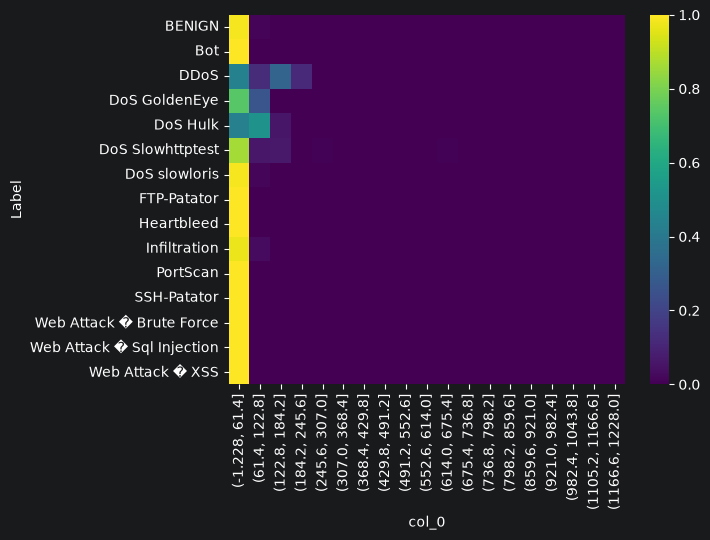

In [78]:
diff.reset_index(drop=True, inplace=True)
t2 = pd.crosstab(df['Label'], pd.cut(diff, bins=20), normalize='index')
sns.heatmap(t2, cmap='viridis')
plt.savefig(Path(plt_path, "Packet Length Mean Copy Check 3.png"))

From these investigations, it can be seen that some attacks produce constant or consistent Pkt Size Ratio, this is valuable insight. Better **not drop these columns: Average Packet Size, Packet Length Mean, Pkt Size Ratio.**

In [79]:
sp = Path('../config/preprocessing/validation_shema.yaml')
schema_cfg = load_validation_schema(sp)

schema_result = validate_schema(df = df, schema_cfg=schema_cfg)
print(schema_result)
print('\n\n\n')
print(schema_result.invalid.keys())

Schema Validation Result
-----------------
NaN:  0
Inf:  2775
Negative:  3495
Out of range values:  2792151
-----------------
NOTE: These are number of cell values not rows.




dict_keys(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',

In [80]:
rp = Path('../config/preprocessing/validation_rules.yaml')
rules_cfg = load_validation_rules(rp)
rule_result = validate_rules(df=df, rules_cfg=rules_cfg)
print(rule_result)
print("\n\n\n")
print(rule_result.violators)

R001: 0
R002: 0
R003: 0
R004: 0
R005: 0
R006: 0
R007: 0
R008: 0
R009: 0
R010: 0
R011: 69
R012: 0
R013: 35
R014: 21291
R015: 0
R016: 0
R017: 0
R018: 1671
R019: 2143





{'R001': set(), 'R002': set(), 'R003': set(), 'R004': set(), 'R005': set(), 'R006': set(), 'R007': set(), 'R008': set(), 'R009': set(), 'R010': set(), 'R011': {np.int64(1932672), np.int64(1871361), np.int64(2174977), np.int64(492419), np.int64(449798), np.int64(495623), np.int64(1485318), np.int64(1491207), np.int64(1663753), np.int64(2182026), np.int64(1376015), np.int64(1499152), np.int64(1371793), np.int64(453138), np.int64(1524113), np.int64(1606036), np.int64(1284117), np.int64(1932689), np.int64(1499161), np.int64(1369883), np.int64(504476), np.int64(1941148), np.int64(1371806), np.int64(458783), np.int64(1524126), np.int64(1562400), np.int64(2175010), np.int64(2181404), np.int64(1183400), np.int64(1496360), np.int64(445227), np.int64(1934003), np.int64(1487800), np.int64(2183226), np.int64(1935805), np.int64(4426

In [81]:
cleaning_cfg = load_cleaning_configuration('../config/preprocessing/cleaning.yaml')

validation_result = ValidationResult(schema_result, rule_result, cleaning_cfg, rules_cfg)

print(validation_result)

Validation Result
----------------------
Repairable: 0
Non-repairable: 1876744
NaN*: 0
Inf*: 2775
Negative*: 3495
Out Of range*: 2792151
Rule violators: {'R001': np.int64(0), 'R002': np.int64(0), 'R003': np.int64(0), 'R004': np.int64(0), 'R005': np.int64(0), 'R006': np.int64(0), 'R007': np.int64(0), 'R008': np.int64(0), 'R009': np.int64(0), 'R010': np.int64(0), 'R011': np.int64(69), 'R012': np.int64(0), 'R013': np.int64(35), 'R014': np.int64(21291), 'R015': np.int64(0), 'R016': np.int64(0), 'R017': np.int64(0), 'R018': np.int64(1671), 'R019': np.int64(2143)}----------------------
NOTE: those marked with * are showing individual cell value count, not row.
Just so you know, a single row can have multiple NaN, Inf, Negative etc. values.


In [82]:
df = clean(validation_result, df, cleaning_cfg)

schema_result_post_clean = validate_schema(df, schema_cfg)
rule_result_post_clean = validate_rules(df, rules_cfg)

print(schema_result_post_clean)
print('\n\n\n')
print(rule_result_post_clean)

Schema Validation Result
-----------------
NaN:  0
Inf:  0
Negative:  0
Out of range values:  0
-----------------
NOTE: These are number of cell values not rows.




R001: 0
R002: 0
R003: 0
R004: 0
R005: 0
R006: 0
R007: 0
R008: 0
R009: 0
R010: 0
R011: 0
R012: 0
R013: 0
R014: 0
R015: 0
R016: 0
R017: 0
R018: 0
R019: 0



In [83]:
validation_result = ValidationResult(schema_result_post_clean, rule_result_post_clean, cleaning_cfg, rules_cfg)

df = df.drop(index=validation_result.non_repairable)

schema_result_final = validate_schema(df, schema_cfg)
rule_result_final = validate_rules(df, rules_cfg)

print(schema_result_final)
print('\n\n\n')
print(rule_result_final)

Schema Validation Result
-----------------
NaN:  0
Inf:  0
Negative:  0
Out of range values:  0
-----------------
NOTE: These are number of cell values not rows.




R001: 0
R002: 0
R003: 0
R004: 0
R005: 0
R006: 0
R007: 0
R008: 0
R009: 0
R010: 0
R011: 0
R012: 0
R013: 0
R014: 0
R015: 0
R016: 0
R017: 0
R018: 0
R019: 0



Cleaning may reintroduce or leave some invalid values, so it's **best to drop any remaining  invalid values and revalidate.**

In [84]:
df.select_dtypes(include='number').agg('std')

Destination Port                 24755.57
Flow Duration                 26500137.98
Total Fwd Packets                    7.94
Total Backward Packets               8.11
Total Length of Fwd Packets       1341.26
                                  ...    
Idle Mean                      8771367.49
Idle Std                       2459747.13
Idle Max                       9660751.90
Idle Min                       8425586.81
Pkt Size Ratio                       0.18
Length: 78, dtype: float64

Looking at the above data, many rows are constant or almost constant, but this is not enough to decide and drop columns, further investigation is needed.

In [85]:
corr = df.corr(numeric_only=True)
out_data_path = Path('../out/data/')
out_data_path.mkdir(parents=True, exist_ok=True)
# corr.to_csv(Path(out_data_path, 'corr.csv'))
corr

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Pkt Size Ratio
Destination Port,1.00,-0.27,-0.24,-0.18,-0.11,-0.17,-0.30,0.07,-0.24,-0.28,...,0.02,-0.09,-0.08,-0.11,-0.06,-0.18,-0.07,-0.18,-0.17,0.34
Flow Duration,-0.27,1.00,0.45,0.36,0.23,0.27,0.53,-0.04,0.34,0.44,...,-0.06,0.23,0.30,0.38,0.09,0.62,0.26,0.63,0.58,-0.51
Total Fwd Packets,-0.24,0.45,1.00,0.95,0.83,0.75,0.50,-0.05,0.41,0.42,...,-0.02,0.28,0.29,0.38,0.15,0.20,0.11,0.21,0.18,-0.49
Total Backward Packets,-0.18,0.36,0.95,1.00,0.79,0.72,0.44,-0.04,0.33,0.35,...,-0.02,0.25,0.22,0.32,0.15,0.15,0.06,0.15,0.13,-0.42
Total Length of Fwd Packets,-0.11,0.23,0.83,0.79,1.00,0.52,0.32,-0.00,0.36,0.30,...,-0.01,0.27,0.25,0.32,0.14,0.11,0.10,0.13,0.09,-0.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Idle Mean,-0.18,0.62,0.20,0.15,0.11,0.11,0.26,-0.00,0.24,0.25,...,-0.04,0.21,0.15,0.21,0.16,1.00,0.28,0.97,0.98,-0.32
Idle Std,-0.07,0.26,0.11,0.06,0.10,0.05,0.06,-0.00,0.16,0.07,...,-0.00,0.23,0.33,0.26,0.02,0.28,1.00,0.48,0.08,-0.13
Idle Max,-0.18,0.63,0.21,0.15,0.13,0.11,0.25,-0.00,0.27,0.24,...,-0.04,0.28,0.27,0.29,0.15,0.97,0.48,1.00,0.91,-0.32
Idle Min,-0.17,0.58,0.18,0.13,0.09,0.09,0.25,-0.00,0.21,0.24,...,-0.04,0.17,0.08,0.16,0.16,0.98,0.08,0.91,1.00,-0.30


## Perfect Positive Correlation (r = +1.000)



| Feature 1                   | Feature 2            | Correlation |
|-----------------------------|----------------------|------------:|
| Total Fwd Packets           | Subflow Fwd Packets  |     +1.0000 |
| Total Backward Packets      | Subflow Bwd Packets  |     +1.0000 |
| Total Length of Fwd Packets | Subflow Fwd Bytes    |     +1.0000 |
| Total Length of Bwd Packets | Subflow Bwd Bytes    |     +1.0000 |
| Fwd Packet Length Mean      | Avg Fwd Segment Size |     +1.0000 |
| Bwd Packet Length Mean      | Avg Bwd Segment Size |     +1.0000 |
| Fwd PSH Flags               | SYN Flag Count       |     +1.0000 |
| Fwd URG Flags               | CWE Flag Count       |     +1.0000 |

---

## Very High Positive Correlation (0.95 ≤ r < 1.00)

| Feature 1                   | Feature 2              | Correlation |
|-----------------------------|------------------------|------------:|
| Flow Duration               | Fwd IAT Total          |     +0.9967 |
| Packet Length Mean          | Average Packet Size    |     +0.9938 |
| RST Flag Count              | ECE Flag Count         |     +0.9915 |
| Flow Duration               | Bwd IAT Total          |     +0.9857 |
| Flow Packets/s              | Bwd Packets/s          |     +0.9852 |
| Flow IAT Max                | Fwd IAT Max            |     +0.9841 |
| Flow Packets/s              | Fwd Packets/s          |     +0.9827 |
| Fwd IAT Total               | Bwd IAT Total          |     +0.9820 |
| Idle Mean                   | Idle Min               |     +0.9787 |
| Idle Mean                   | Idle Max               |     +0.9712 |
| Packet Length Std           | Packet Length Variance |     +0.9706 |
| Total Fwd Packets           | Fwd Header Length      |     +0.9679 |
| Fwd Header Length           | Subflow Fwd Packets    |     +0.9679 |
| Fwd Header Length           | Fwd Header Length.1    |     +0.9640 |
| Total Length of Fwd Packets | Fwd Packet Length Max  |     +0.9630 |
| Idle Max                    | Idle Min               |     +0.9619 |
| Flow Bytes/s                | Bwd Bytes/s            |     +0.9608 |
| Flow Bytes/s                | Fwd Bytes/s            |     +0.9574 |
| Flow IAT Std                | Fwd IAT Std            |     +0.9550 |
| Fwd Packet Length Max       | Avg Fwd Segment Size   |     +0.9523 |
| Total Length of Fwd Packets | Avg Fwd Segment Size   |     +0.9523 |

---

## High Positive Correlation (0.90 ≤ r < 0.95)

- Total Length of Bwd Packets ↔ Bwd Packet Length Max
- Total Length of Bwd Packets ↔ Avg Bwd Segment Size
- Bwd Packet Length Mean ↔ Bwd Packet Length Max
- Packet Length Mean ↔ Fwd Packet Length Mean
- Packet Length Mean ↔ Bwd Packet Length Mean
- Packet Length Mean ↔ Avg Fwd Segment Size
- Packet Length Mean ↔ Avg Bwd Segment Size
- Average Packet Size ↔ Fwd Packet Length Mean
- Average Packet Size ↔ Bwd Packet Length Mean
- Average Packet Size ↔ Avg Fwd Segment Size
- Average Packet Size ↔ Avg Bwd Segment Size
- Packet Length Std ↔ Bwd Packet Length Std
- Idle Std ↔ Idle Max
- Flow IAT Mean ↔ Fwd IAT Mean
- Flow IAT Max ↔ Bwd IAT Max
- Active Mean ↔ Active Max
- Total Backward Packets ↔ Bwd Header Length
- Bwd Header Length ↔ Subflow Bwd Packets

**Total feature pairs with |r| ≥ 0.90:** **65**

---

## High Negative Correlation

| Feature 1      | Feature 2      | Correlation |
|----------------|----------------|------------:|
| PSH Flag Count | ACK Flag Count |     -0.9403 |

---

## Observations

Several highly correlated features are expected because the CICFlowMeter feature extraction process generates multiple representations of the same underlying network statistic.

### Duplicate Features

| Original Feature            | Duplicate Feature   |
|-----------------------------|---------------------|
| Total Fwd Packets           | Subflow Fwd Packets |
| Total Backward Packets      | Subflow Bwd Packets |
| Total Length of Fwd Packets | Subflow Fwd Bytes   |
| Total Length of Bwd Packets | Subflow Bwd Bytes   |

These pairs are perfectly correlated (`r = 1.0`) and contain identical information.

### Equivalent Statistics

| Feature                | Equivalent Feature   |
|------------------------|----------------------|
| Packet Length Mean     | Average Packet Size  |
| Fwd Packet Length Mean | Avg Fwd Segment Size |
| Bwd Packet Length Mean | Avg Bwd Segment Size |

These features are mathematically equivalent or derived using the same computation.

---

## Preliminary Conclusion

There are several highly correlated values in the Dataset, possibly due to CICFlowMaker calculating them using the same formulas / underlying logic. I need to investigate if they are worth keeping.

In [86]:
numeric_columns = df.columns.drop('Label')

df_z_score = df.copy(deep=False)

df_z_score[numeric_columns] = (df[numeric_columns] - df[numeric_columns].mean()) / df[numeric_columns].std()

# df_z_score.to_csv(Path(out_data_path, 'df_z_score_1.csv'))
df_z_score

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Pkt Size Ratio
1,1.38,-0.33,-0.33,-0.26,-0.14,-0.20,-0.41,0.41,-0.32,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,1.15
2,1.38,-0.33,-0.33,-0.26,-0.14,-0.20,-0.41,0.41,-0.32,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,1.15
3,1.02,-0.33,-0.33,-0.26,-0.14,-0.20,-0.41,0.41,-0.32,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,1.15
7,1.37,-0.33,-0.33,-0.26,-0.14,-0.20,-0.41,0.41,-0.32,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,1.15
14,0.61,-0.33,-0.33,-0.26,-0.14,-0.21,-0.44,-0.23,-0.48,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2522349,1.13,-0.33,-0.33,-0.26,-0.14,-0.21,-0.44,-0.23,-0.48,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,NaN
2522351,-0.83,-0.33,-0.08,-0.26,-0.13,-0.20,-0.41,0.41,-0.32,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,-0.26
2522353,0.58,-0.33,-0.33,-0.26,-0.14,-0.21,-0.44,-0.23,-0.48,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,NaN
2522356,1.15,-0.33,-0.33,-0.26,-0.14,-0.21,-0.44,-0.23,-0.48,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,NaN


There are some Z score values who are NaN:
* Fwd Avg Bytes/Bulk
* Fwd Avg Packets/Bulk
* Fwd Avg Bulk Rate
* Bwd Avg Bytes/Bulk
* Bwd Avg Packets/Bulk
* Bwd Avg Bulk Rate
* Bwd PSH Flag
* Bwd URG Flag

For now, I'll replace them with zero to continue, but for them to be zero it means they are constant (std = 0), they basically contribute nothing to the model's learning.

Upon research found that the CICIDS2017 has almost no Bulk transfers (or actually none), this means all should be zero, hence no deviation. Same goes for the listed flags. As such we can safely **drop them.**

In [87]:
df_z_score.replace(to_replace=np.nan, value=0, inplace=True)
# df_z_score.to_csv(Path(out_data_path, 'df_z_score_2.csv'))
df_z_score

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Pkt Size Ratio
1,1.38,-0.33,-0.33,-0.26,-0.14,-0.20,-0.41,0.41,-0.32,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,1.15
2,1.38,-0.33,-0.33,-0.26,-0.14,-0.20,-0.41,0.41,-0.32,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,1.15
3,1.02,-0.33,-0.33,-0.26,-0.14,-0.20,-0.41,0.41,-0.32,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,1.15
7,1.37,-0.33,-0.33,-0.26,-0.14,-0.20,-0.41,0.41,-0.32,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,1.15
14,0.61,-0.33,-0.33,-0.26,-0.14,-0.21,-0.44,-0.23,-0.48,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2522349,1.13,-0.33,-0.33,-0.26,-0.14,-0.21,-0.44,-0.23,-0.48,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,0.00
2522351,-0.83,-0.33,-0.08,-0.26,-0.13,-0.20,-0.41,0.41,-0.32,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,-0.26
2522353,0.58,-0.33,-0.33,-0.26,-0.14,-0.21,-0.44,-0.23,-0.48,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,0.00
2522356,1.15,-0.33,-0.33,-0.26,-0.14,-0.21,-0.44,-0.23,-0.48,-0.44,...,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,BENIGN,0.00


In [88]:
df_z_score = df_z_score.groupby(by="Label").mean()
# df_z_score.to_csv(Path(out_data_path, 'df_z_score_3.csv'))
df_z_score

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Pkt Size Ratio
Label,,,,,,,,,,,,,,,,,,,,,
BENIGN,0.12,0.04,0.04,0.02,0.01,0.02,0.06,0.02,0.05,0.07,...,-0.15,-0.01,-0.03,-0.01,0.01,0.01,-0.02,-0.00,0.01,-0.17
Bot,-0.11,-0.32,-0.13,-0.10,-0.08,-0.15,-0.04,0.02,0.06,0.08,...,-0.66,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,-0.06
DDoS,-0.78,-0.12,-0.11,-0.22,-0.13,-0.20,-0.39,0.27,-0.31,-0.41,...,-0.98,0.10,-0.09,-0.01,0.20,0.19,0.67,0.29,0.06,0.00
DoS GoldenEye,-0.84,3.63,-0.11,-0.25,0.32,-0.20,1.73,-0.23,4.84,3.70,...,0.84,0.42,0.52,0.39,0.10,11.07,0.40,10.24,11.44,0.12
DoS Hulk,-0.84,-0.19,-0.15,-0.20,-0.13,-0.21,-0.41,0.35,-0.34,-0.44,...,-0.84,-0.10,-0.08,-0.12,-0.07,0.03,0.41,0.09,-0.06,-0.18
DoS Slowhttptest,-0.84,2.19,0.20,-0.12,0.37,-0.21,1.41,0.33,2.18,1.87,...,0.84,1.98,0.50,1.28,2.04,6.16,0.19,5.70,6.38,-0.66
DoS slowloris,-0.84,2.88,0.73,-0.08,0.95,-0.18,0.48,0.50,2.46,0.67,...,0.84,4.87,7.12,5.37,0.37,3.57,4.41,5.06,2.81,-0.84
FTP-Patator,-0.85,-0.10,0.39,0.91,-0.08,-0.06,-0.33,-0.23,-0.21,-0.29,...,0.84,-0.11,-0.09,-0.13,-0.07,-0.24,-0.09,-0.24,-0.23,-0.91
Infiltration,-0.83,2.51,41.52,40.72,69.94,2.12,3.60,0.32,4.30,2.59,...,-0.90,8.94,2.25,6.57,9.64,2.71,4.39,3.45,1.96,-1.30


In [89]:
df_z_score = df_z_score - df_z_score.loc['BENIGN']
# df_z_score.to_csv(Path(out_data_path, 'df_z_score_4.csv'))
df_z_score

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Pkt Size Ratio
Label,,,,,,,,,,,,,,,,,,,,,
BENIGN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Bot,-0.23,-0.35,-0.16,-0.12,-0.10,-0.17,-0.10,0.00,0.00,0.01,...,-0.52,-0.09,-0.07,-0.12,-0.08,-0.24,-0.07,-0.24,-0.24,0.10
DDoS,-0.90,-0.16,-0.15,-0.24,-0.14,-0.23,-0.45,0.25,-0.37,-0.48,...,-0.84,0.12,-0.07,-0.00,0.19,0.18,0.69,0.29,0.05,0.17
DoS GoldenEye,-0.97,3.59,-0.15,-0.27,0.31,-0.23,1.67,-0.24,4.79,3.63,...,0.98,0.43,0.54,0.40,0.09,11.07,0.42,10.24,11.43,0.28
DoS Hulk,-0.97,-0.23,-0.19,-0.22,-0.14,-0.23,-0.47,0.33,-0.39,-0.51,...,-0.69,-0.09,-0.05,-0.11,-0.08,0.02,0.43,0.09,-0.07,-0.01
DoS Slowhttptest,-0.97,2.16,0.16,-0.14,0.36,-0.23,1.35,0.31,2.12,1.80,...,0.98,1.99,0.53,1.28,2.04,6.16,0.20,5.70,6.36,-0.49
DoS slowloris,-0.97,2.85,0.70,-0.10,0.94,-0.21,0.42,0.49,2.41,0.61,...,0.98,4.88,7.15,5.38,0.36,3.57,4.42,5.06,2.79,-0.68
FTP-Patator,-0.97,-0.14,0.35,0.89,-0.10,-0.09,-0.39,-0.24,-0.27,-0.36,...,0.98,-0.09,-0.07,-0.12,-0.08,-0.25,-0.07,-0.24,-0.24,-0.74
Infiltration,-0.95,2.47,41.48,40.70,69.92,2.09,3.54,0.30,4.24,2.52,...,-0.75,8.95,2.27,6.58,9.63,2.70,4.41,3.46,1.94,-1.13


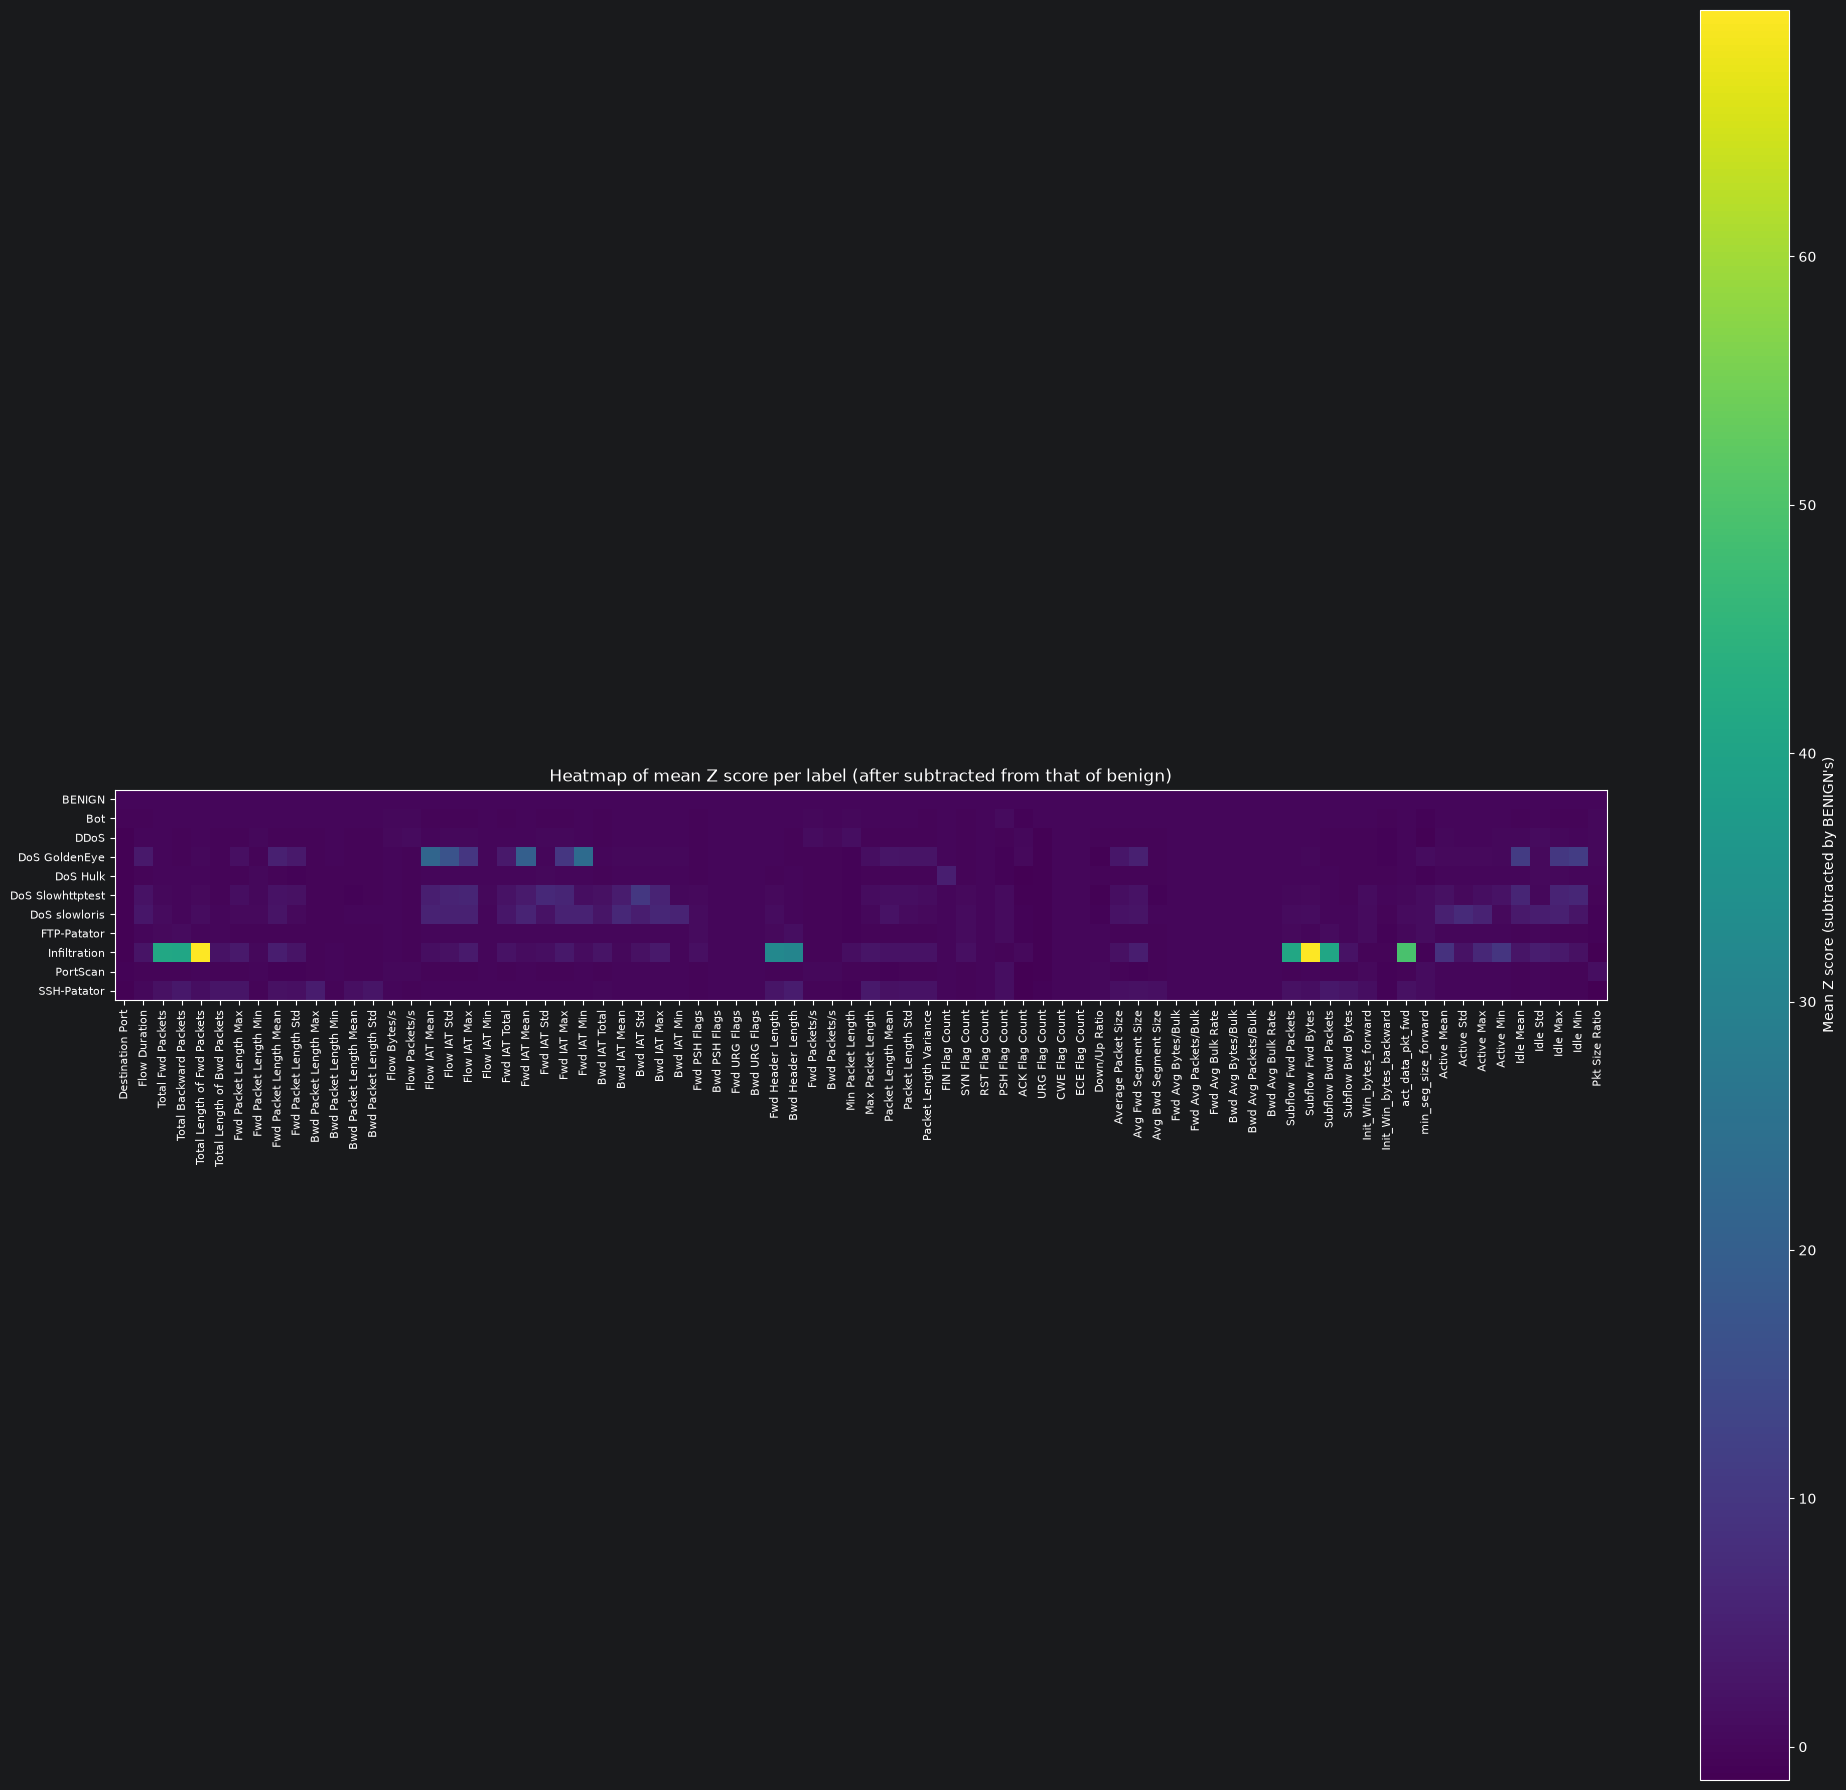

In [90]:
plt.figure(figsize=(20, 18))

plt.imshow(df_z_score, cmap='viridis')
plt.colorbar(label = "Mean Z score (subtracted by BENIGN's)")

plt.xticks(
    range(len(df_z_score.columns)),
    df_z_score.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(df_z_score.index)),
    df_z_score.index,
    fontsize = 8
)

plt.title("Heatmap of mean Z score per label (after subtracted from that of benign)")
plt.tight_layout()
plt.savefig(Path(plt_path,  'Z score heatmap.png'))
plt.show()

It can be seen that the behavior of some attacks is largely similar to that of the benign, while some have really high difference,like that of Infiltration. Also, the value of Z-score difference ranges from 0 to 70.

The identical behavior of various columns across various attacks can be attributed to the fact that many columns initially had NaN as a Z-score which were later replaced with  0.

I noticed Fwd URG Flags column has zero std but still has a zscore value. This needs to be investigated.

In [91]:
print(df['Fwd URG Flags'].value_counts(dropna=False))
print(df['Fwd URG Flags'].unique())
print(df['Fwd URG Flags'].nunique())

Fwd URG Flags
0    645610
1         8
Name: count, dtype: int64
[0 1]
2


In [92]:
std = df["Fwd URG Flags"].std()

print(repr(std))
print(f"{std:.20f}")

np.float64(0.00352009856390325)
0.00352009856390325020


Ok so the std was so small that it was rounded to zero.

In [93]:
df["Label"].values.unique()

<StringArray>
[          'BENIGN',             'DDoS',         'PortScan',
              'Bot',     'Infiltration',      'FTP-Patator',
      'SSH-Patator',    'DoS slowloris', 'DoS Slowhttptest',
         'DoS Hulk',    'DoS GoldenEye']
Length: 11, dtype: str

Looking at the labels we're currently left with, it appears 4 labels have dissapeared, namely:
* Heartbleed
* Web Attack - SQL Injection
* Web Attack - XSS
* Web Attack - Brute Force

Upon investigation, found that they disappeared in the cleaning step, apparently they were in the rows that were invalid and not repairable. Such data cannot be used to train the models, otherwise model will learn corrupted parameters. As such I will have to drop them from the IDS system for now.

However, I'll keep the system's functionalities to work on them so that when in later versions I introduce simulations the system would be able to learn these attack classes and indentify them.